In [1680]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats
from sklearn import datasets
import collections
import itertools
import statsmodels

rng = np.random.default_rng()
np.set_printoptions(linewidth=100)

# Block 4

## Prac 0
... TODO

## Prac 1

### 1.
Наблюдения 16 пар $(X,Y)$ дали следующие результаты:

   $$ \sum X = 96,\quad \sum Y = 64 $$
   $$ \sum X^2 = 657,\quad \sum Y^2 = 526,\quad \sum XY = 492 $$

   Оцените регрессию $y_i = a + bx_i$ и проверьте гипотезу о том, что коэффициент $b$ равен единице.

In [1681]:
N = 16

X_sum = 96
X2_sum = 657

Y_sum = 64
Y2_sum = 526

XY_sum = 492

##

b = (N * XY_sum - X_sum * Y_sum) / (N * X2_sum - X_sum ** 2)
a = Y_sum / N - b * X_sum / N
a, b

(-4.0, 1.3333333333333333)

$$ \sigma_b^2 = D[b] = D\left[ \frac{cov(X, Y)}{\sigma_X^2} \right] =
D\left[ \frac{\sum(X_i - \bar{X})(Y_i - \bar{Y})}{\sigma_X^2} \right] = \\
= D\left[ \frac{\sum(X_i - \bar{X})Y_i}{\sigma_X^2} \right] = \left( \frac{\sum(X_i - \bar{X})}{\sigma_X^2} \right)^2 D[Y_i] = \frac{1}{\sigma_X^2} \sigma^2 = \\
= \frac{1}{\sigma_X^2} \hat{\sigma}^2 = \frac{1}{\sigma_X^2} \frac{1}{n-2} \sum(Y_i - \hat{Y}_i)^2
$$

$$
\sum(Y_i - \hat{Y}_i)^2 = \sum(Y_i - \hat{Y}_i)Y_i - \sum \overbrace{(Y_i - \hat{Y}_i)}^{0} \hat{Y}_i = \\
= \sum Y_i^2 - a \sum Y_i - b \sum X_i Y_i
$$

In [1682]:
std2_X = X2_sum - X_sum ** 2 / N
std2 = (Y2_sum - a * Y_sum - b * XY_sum)/(N - 2)

# std_X
std2_b = std2 / std2_X
std_b = np.sqrt(std2_b)

std_b, std2_b, std2, std2_X

(np.float64(0.3333333333333333), 0.1111111111111111, 9.0, 81.0)

$H_0: b = (b_0 = 1)$

In [1683]:
b0 = 1
t = np.abs(b - b0) / std_b

alpha = 0.05
t_crit = stats.t.ppf(1-alpha / 2, df=N-2)
p_value = stats.t.sf(t, df=N-2) * 2

print(f"{t = }\n{t_crit = }\n{p_value = }")

t = np.float64(0.9999999999999998)
t_crit = np.float64(2.1447866879169273)
p_value = np.float64(0.33428194339465744)


Не отвергаем, поскольку $1 < 2.14$ ($0.05 < 0.33$)

### 2.
Менеджер новой чебуречной не уверен в правильности новой цены на чебуреки, поэтому в течение 12 недель он варьирует цену и записывает количество проданных чебуреков:

| Неделя $i$ | Цена $p_i$ (тугрики) |  Количество $q_i$ |
|------------|------------------|----------------------|
| 1	       |  12.3	           | 795     |
| 2	       |  11.5	           | 915     |
| 3	       |  11.0	           | 965     |
| 4	       |  12.0	           | 892     |
| 5	       |  13.5	           | 585     |
| 6	       |  12.5	           | 644     |
| 7	       |  12.8	           | 714     |
| 8	       |  9.9	           | 1180    |
| 9	       |  12.2	           | 851     |
| 10         |	12.5	           | 779     |
| 11         |	13.0	           | 625     |
| 12         |	10.5	           | 1001    |

a) Оцените параметры модели: $\ln q_i = a + b \ln p_i$

b) На основе полученных оценок модели найдите оптимальную цену чебурека (в смысле максимума выручки от продаж).

In [1684]:
p = np.array([12.3, 11.5, 11.0, 12.0, 13.5, 12.5, 12.8, 9.9, 12.2, 12.5, 13.0, 10.5])
q = np.array([795, 915, 965, 892, 585, 644, 714, 1180, 851, 779, 625, 1001])

x = np.log(p)
y = np.log(q)
n = p.shape[0]

b = (n * (x * y).sum() - x.sum() * y.sum())/(n * (x**2).sum() - (x.sum())**2)
a = y.mean() - b * x.mean()
a, b

(np.float64(12.026909018302023), np.float64(-2.148860055896859))

$$ R = p \cdot q = p (e^a p^b) = e^a p^{b+1} $$
$$ \frac{dR}{dp} = e^a (b+1) p^b < 0 $$
Следовательно, выручка уменьшается при увеличении цены, а значит максимум - при минимальной цене. ($i = 8, \, p = 9.9$)

# Prac 2

## 1.
Имеются данные о стоимости б/у автомобилей (результативная переменная $y$, тугриков) в некотором регионе, о годе выпуска (возраст автомобиля — фактор $x_1$, лет) и о пробеге (фактор $x_2$, тыс. км). (*данные_авто.doc*)

   - Проведите предварительную подготовку, обработку и проверку данных:
     1. Постройте гистограмму по рядам наблюдений.
     2. Постройте корреляционную матрицу для независимых переменных.
     3. Рассчитайте основные статистические показатели рядов данных (количество наблюдений, среднее, среднеквадратическое отклонение, минимальное и максимальное значение и т.д.).
   - Составьте уравнение множественной линейной регрессии.
   - Оцените статистическую значимость параметров регрессионной модели с помощью $t$-статистики. Гипотезу о значимости уравнения в целом проверьте с помощью $F$-критерия.


In [1685]:
# Вариант 3

y =  np.array([90, 70, 45, 80, 80, 85, 97, 70, 70, 50, 68, 60, 90, 82, 50])
x1 = np.array([7, 6, 16, 6, 6, 6, 6, 6, 9, 6, 11, 9, 8, 7, 16])
x2 = np.array([100, 107, 90, 120, 60, 96, 59, 115, 110, 117, 71, 90, 136, 83, 170])

n = y.shape[0]
k = 3

data = np.array([y, x1, x2])
df = pd.DataFrame(data.T, columns=["y", "x1", "x2"])
df

,y,x1,x2
0,90,7,100
1,70,6,107
2,45,16,90
3,80,6,120
4,80,6,60
5,85,6,96
6,97,6,59
7,70,6,115
8,70,9,110
9,50,6,117


array([[<Axes: title={'center': 'y'}>, <Axes: title={'center': 'x1'}>],
       [<Axes: title={'center': 'x2'}>, <Axes: >]], dtype=object)

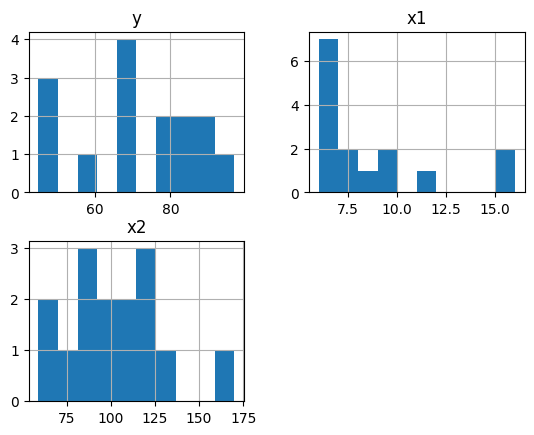

In [1686]:
df.hist()

In [1687]:
np.corrcoef(data[1:])

array([[1.        , 0.32244038],
       [0.32244038, 1.        ]])

In [1688]:
def _stats(_x: np.ndarray):
    print(f"size={_x.shape[0]}, mean={_x.mean()}, std={_x.std()}, min={_x.min()}, max={_x.max()}, median={np.median(_x)}")

_stats(y)
_stats(x1)
_stats(x2)

size=15, mean=72.46666666666667, std=15.353030826372867, min=45, max=97, median=70.0
size=15, mean=8.333333333333334, std=3.3399933466334266, min=6, max=16, median=7.0
size=15, mean=101.6, std=28.104092228712883, min=59, max=170, median=100.0


Уравнение регрессии: $y = b_0 + b_1 x_1 + b_2 x_2$

In [1689]:
X_am = np.array([[1]*y.shape[0], x1, x2]).T
X_am

array([[  1,   7, 100],
       [  1,   6, 107],
       [  1,  16,  90],
       [  1,   6, 120],
       [  1,   6,  60],
       [  1,   6,  96],
       [  1,   6,  59],
       [  1,   6, 115],
       [  1,   9, 110],
       [  1,   6, 117],
       [  1,  11,  71],
       [  1,   9,  90],
       [  1,   8, 136],
       [  1,   7,  83],
       [  1,  16, 170]])

In [1690]:
var_am = np.linalg.inv(X_am.T @ X_am)
b_am = var_am @ X_am.T @ y
(*b_am,)

(np.float64(104.0851687489511),
 np.float64(-2.7906045455077666),
 np.float64(-0.08231756105367144))

In [1691]:
y_am_hat = X_am @ b_am
y - y_am_hat

array([ 13.68081917,  -8.53356244,  -7.02691553,   2.53656585,  -2.40248781,   5.56094439,
        14.51519463,  -7.87502195,   0.08520388, -27.71038683,   0.45602809, -11.56114734,
        19.43485592,   4.28142064,   4.55848936])

In [1692]:
var_am

array([[ 1.06942657e+00, -2.96127681e-02, -7.44081530e-03],
       [-2.96127681e-02,  6.66950990e-03, -2.55575601e-04],
       [-7.44081530e-03, -2.55575601e-04,  9.41989367e-05]])

$$ \sigma_{\hat{b}}^2 = \sigma^2 (X^T X)^{-1} $$
$$ \sigma_{\hat{b_i}}^2 = \sigma^2 ((X^T X)^{-1})_{ii} $$

In [1693]:
std_am = np.sqrt(((y - y_am_hat)**2).sum() / (n - k))
std_am, std_am**2

(np.float64(12.727156023924158), np.float64(161.98050045730898))

In [1694]:
std_b = std_am * np.sqrt( var_am.diagonal() )
std_b, std_b**2

(array([13.16154439,  1.03938951,  0.12352486]),
 array([1.73226251e+02, 1.08033055e+00, 1.52583909e-02]))

In [1695]:
t_am = b_am / std_b
t_am

array([ 7.90827928, -2.68484964, -0.66640481])

In [1696]:
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha / 2, df=n-k)
p_value = stats.t.sf(np.abs(t_am), df=n-k) * 2

print(f"{np.abs(t_am) = }\n{t_crit = }\n{p_value = }\n{np.abs(t_am) > t_crit = } - H_0 отвергаем")

np.abs(t_am) = array([7.90827928, 2.68484964, 0.66640481])
t_crit = np.float64(2.1788128296634177)
p_value = array([4.23019641e-06, 1.98580773e-02, 5.17759760e-01])
np.abs(t_am) > t_crit = array([ True,  True, False]) - H_0 отвергаем


* $ b_0, b_1 $ значимые, поскольку $7.9, 2.6 > 2.16$ (Отвергаем $H_0 : b_i = 0$)
* $ b_2 : 0.6 < 2.16$, не отвергаем $H_0: b_2 = 0$.

In [1697]:
R2 = 1 - (( y - y_am_hat )**2).sum() / (( y - y.mean() )**2).sum()
R2

np.float64(0.4502509600589105)

In [1698]:
alpha = 0.05

F = R2 / (k - 1) / ((1 - R2) / (n - k))
F_crit = stats.f.ppf(1-alpha, k - 1, n - k)
p_value = stats.t.sf(F, df=N-k)


print(f"{F = }\n{F_crit = }\n{p_value = }\n{F > F_crit = } - H_0 отвергаем")

F = np.float64(4.914070901593487)
F_crit = np.float64(3.885293834652391)
p_value = np.float64(0.00014146249424908333)
F > F_crit = np.True_ - H_0 отвергаем


$H_0$ - равенство всех коэф. нулю - отвергается. Регрессия статистически значима.

## 2. 
На встроенных данных `iris` постройте регрессию, в которой длина чашелистика (*sepal length*) — зависимая переменная, а ширина и длина лепестка, а также ширина чашелистика — предикторы.
   - Оцените качество регрессии. Проинтерпретируйте коэффициенты.
   - Постройте корреляционную матрицу переменных модели. Подумайте, нужно ли исключить из модели часть предикторов (используйте VIF).
   - Проанализируйте финальную модель и сравните её с исходной.

In [1699]:
iris = datasets.load_iris()
print(iris.feature_names)
pd.DataFrame(data=iris.data, columns=iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [1700]:
iris_y = iris.data[:, 0]
iris_x = iris.data[:].copy()
iris_x[:, 0] = 1

n = iris_y.shape[0]
k = iris_x.shape[1]

iris_y, iris_x

(array([5.1, 4.9, 4.7, 4.6, 5. , 5.4, 4.6, 5. , 4.4, 4.9, 5.4, 4.8, 4.8, 4.3, 5.8, 5.7, 5.4, 5.1,
        5.7, 5.1, 5.4, 5.1, 4.6, 5.1, 4.8, 5. , 5. , 5.2, 5.2, 4.7, 4.8, 5.4, 5.2, 5.5, 4.9, 5. ,
        5.5, 4.9, 4.4, 5.1, 5. , 4.5, 4.4, 5. , 5.1, 4.8, 5.1, 4.6, 5.3, 5. , 7. , 6.4, 6.9, 5.5,
        6.5, 5.7, 6.3, 4.9, 6.6, 5.2, 5. , 5.9, 6. , 6.1, 5.6, 6.7, 5.6, 5.8, 6.2, 5.6, 5.9, 6.1,
        6.3, 6.1, 6.4, 6.6, 6.8, 6.7, 6. , 5.7, 5.5, 5.5, 5.8, 6. , 5.4, 6. , 6.7, 6.3, 5.6, 5.5,
        5.5, 6.1, 5.8, 5. , 5.6, 5.7, 5.7, 6.2, 5.1, 5.7, 6.3, 5.8, 7.1, 6.3, 6.5, 7.6, 4.9, 7.3,
        6.7, 7.2, 6.5, 6.4, 6.8, 5.7, 5.8, 6.4, 6.5, 7.7, 7.7, 6. , 6.9, 5.6, 7.7, 6.3, 6.7, 7.2,
        6.2, 6.1, 6.4, 7.2, 7.4, 7.9, 6.4, 6.3, 6.1, 7.7, 6.3, 6.4, 6. , 6.9, 6.7, 6.9, 5.8, 6.8,
        6.7, 6.7, 6.3, 6.5, 6.2, 5.9]),
 array([[1. , 3.5, 1.4, 0.2],
        [1. , 3. , 1.4, 0.2],
        [1. , 3.2, 1.3, 0.2],
        [1. , 3.1, 1.5, 0.2],
        [1. , 3.6, 1.4, 0.2],
        [1. , 3.9, 1.7, 0.

In [1806]:
def b_significance(_b: np.ndarray, _X: np.ndarray, _y: np.ndarray, _alpha: float=0.05, _var: np.ndarray=None, _x_names: list[str]=None, is_white_err: bool=False):
    _n = _y.shape[0]
    _k = _X.shape[1]

    _y_hat = _X @ _b

    if _var is None:
        _var = np.linalg.inv( _X.T @ _X )
    elif is_white_err:
        _e2 = (_y - _y_hat)**2
        _mid = (_X.T @ np.diag(_e2) @ _X)
        _var = _var @ _mid @ _var

    _std = np.sqrt(((_y - _y_hat)**2).sum() / (_n - _k))
    _std_b = _std * np.sqrt( np.diag( _var ) )

    _t = _b / _std_b

    _t_crit = stats.t.ppf(1 - _alpha / 2, df=_n-_k)
    _p_value = stats.t.sf(np.abs(_t), df=_n-_k) * 2

    print(f"b_significance ({_alpha = })\n{_t_crit = }")

    # print(f"{_t = }\n{_b = }\n{_std_b}")
    
    def _print(index, bs, ts, std_bs, p_vals, name=""):
        is_intercept = np.isclose(_X[:, index], 1).all()
        ind = index == 0 and is_intercept and "const" or index
        print(f"{ind:<5} {bs:>12.3f} {std_bs:>10.3f} {ts:>10.3f} {p_vals:>10.4f} {name:>12}")

    print(f"{"n":<5} {"param":>12} {"t-stat":>10} {"std err":>10} {"p_value":>10}")
    for i, (b, t, std, p) in enumerate(zip(_b, _std_b, _t, _p_value)):
        _print(i, b, t, std, p, _x_names[i] if _x_names is not None else "")




In [1702]:
R2_res = collections.namedtuple("R2_res", ["R2", "R2_agj"])

def R2_calc(_b: np.ndarray, _X: np.ndarray, _y: np.ndarray) -> R2_res:
    _n = _y.shape[0]
    _k = _X.shape[1]

    _y_hat = _X @ _b

    _R2 = 1 - (( _y - _y_hat )**2).sum() / (( _y - _y.mean() )**2).sum()

    _R2_adj = 1 - (1 - _R2) * (_n - 1) / (_n - _k)

    return R2_res(_R2, _R2_adj)

In [1703]:
def F_test_lm(_b: np.ndarray, _X: np.ndarray, _y: np.ndarray, _alpha: float = 0.05) -> tuple[float, float]:
    _n, _k = _X.shape

    _R2 = R2_calc(_b, _X, _y)[0]

    if _k > 1:
        _F = _R2 / (_k - 1) / ((1 - _R2) / (_n - _k))
        _F_crit = stats.f.ppf(1 - _alpha, _k - 1, _n - _k)
    else:
        _F = _R2 / (_k) / ((1 - _R2) / (_n - _k))
        _F_crit = stats.f.ppf(1 - _alpha, _k, _n - _k)
        
    _p_value = stats.t.sf(_F, df=_n-_k)

    print(f"F-test ({_alpha = })\n{_F = }\n{_F_crit = }\n{_p_value = }\n{_F > _F_crit = } - H_0 отвергаем")

In [1704]:
def res_normality(_b: np.ndarray, _X: np.ndarray, _y: np.ndarray, _alpha: float = 0.05):
    _y_hat = _X @ _b

    _res = _y - _y_hat

    print("Residuals normality:", stats.normaltest(_res))
    print("Residuals normality:", stats.shapiro(_res))

    # plt.hist(_res)

In [1803]:
def lm(_X: np.ndarray, _y: np.ndarray, verbose: int = 4, mode: str="inv", _x_names: list[str] = None, is_white_err: bool=False, is_add_intercept: bool=False):
    if is_add_intercept:
        _X = np.concat([[[1]]*_X.shape[0], _X], axis=-1)

    match mode:
        case "inv":
            inv = np.linalg.inv
        case "pinv":
            inv = np.linalg.pinv
        case _:
            raise AttributeError(f"Not found mode {mode!r}")

    _var = inv( _X.T @ _X )    
    _b = _var @ _X.T @ _y

    if verbose >= 1:
        b_significance(_b, _X, _y, _var=_var, _x_names=_x_names, is_white_err=is_white_err)
    if verbose >= 2:
        print()
        print(R2_calc(_b, _X, _y))
    if verbose >= 3:
        print()
        F_test_lm(_b, _X, _y)
    if verbose >= 4:
        print()
        res_normality(_b, _X, _y)

    return _b

In [1706]:
iris_b = lm(iris_x, iris_y)

b_significance (_alpha = 0.05)
_t_crit = np.float64(1.9763456545827003)
n            param     t-stat    std err    p_value
const        1.856      7.401      0.251     0.0000             
1            0.651      9.765      0.067     0.0000             
2            0.709     12.502      0.057     0.0000             
3           -0.556     -4.363      0.128     0.0000             

R2_res(R2=np.float64(0.8586117200663178), R2_agj=np.float64(0.8557064814375435))

F-test (_alpha = 0.05)
_F = np.float64(295.5391380117242)
_F_crit = np.float64(2.666574213304177)
_p_value = np.float64(5.667163342724973e-205)
_F > _F_crit = np.True_ - H_0 отвергаем

Residuals normality: NormaltestResult(statistic=np.float64(0.3451277647790554), pvalue=np.float64(0.8415045297745032))
Residuals normality: ShapiroResult(statistic=np.float64(0.9955914223680596), pvalue=np.float64(0.9349086404929375))


* y => 'sepal length (cm)'
* x => 1, 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'

Регрессия значимая.

Длина чашелситика увеличивается от его ширины и длины лепестка, и уменьшается от ширины лепестка.

In [1707]:
print(iris.feature_names)
np.corrcoef(iris.data.T)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


array([[ 1.        , -0.11756978,  0.87175378,  0.81794113],
       [-0.11756978,  1.        , -0.4284401 , -0.36612593],
       [ 0.87175378, -0.4284401 ,  1.        ,  0.96286543],
       [ 0.81794113, -0.36612593,  0.96286543,  1.        ]])

In [1708]:
def R2_xi(_X: np.ndarray):
    _R2_i = []
    for i in range(1, _X.shape[1]):
        _y = _X[:, i]
        _x = np.delete(_X, i, axis=-1)

        _b = np.linalg.inv(_x.T @ _x) @ _x.T @ _y
        _R2_i.append(R2_calc(_b, _x, _y)[0])
        
    return np.array(_R2_i)

def VIF(_X: np.ndarray):
    _R2_i = R2_xi(_X)
    return 1 / (1 - _R2_i)

VIF(iris_x)

array([ 1.27081493, 15.09757232, 14.23433497])

Уберём 'petal width (cm)': VIF > 10, высокая корреляция с 'petal length (cm)'

In [1709]:
lm(iris_x[:, :-1], iris_y)

b_significance (_alpha = 0.05)
_t_crit = np.float64(1.9762333088845878)
n            param     t-stat    std err    p_value
const        2.249      9.070      0.248     0.0000             
1            0.596      8.590      0.069     0.0000             
2            0.472     27.569      0.017     0.0000             

R2_res(R2=np.float64(0.8401778354262203), R2_agj=np.float64(0.8380033842075294))

F-test (_alpha = 0.05)
_F = np.float64(386.386150309707)
_F_crit = np.float64(3.0576206516493882)
_p_value = np.float64(3.097170332788339e-223)
_F > _F_crit = np.True_ - H_0 отвергаем

Residuals normality: NormaltestResult(statistic=np.float64(0.16446190108827397), pvalue=np.float64(0.921059215003771))
Residuals normality: ShapiroResult(statistic=np.float64(0.9939380913871176), pvalue=np.float64(0.7856408514232123))


array([2.24914016, 0.59552475, 0.47192004])

In [1710]:
VIF(iris_x[:, :-1])

array([1.22483113, 1.22483113])

Получилось убрать из модели один предиктор, при этом избавившись от мультиколлинеарности и без значительно потери качества. 

# Prac 3.

## 1.
С целью изучения динамики эвтрификации водоемов, загрязненных минеральными
удобрениями, в пяти прудах моделировали размножение синезеленых водорослей в
нелимитированных условиях. Полученые данные об изменении численности
популяции водорослей в каждом пруду представлены в таблице ниже.

*Теоретические заметки*: Нелимитированный рост численности популяции при
постоянных условиях среды описывается дифференциальным уравнением
Мальтуса (Ризниченко, Рубин, 1993): 
$$ \frac{dx}{dt} = r \cdot x, $$
где $x$ – численность (плотность) популяции, $t$ – время, $r$ – мальтузианский параметр, имеющий смысл удельной скорости роста.

Решением данного уравнения является выражение: $ x_t = x_0 \cdot e^{rt} $, где $x_0$ – начальная численность популяции.

Значение периода удвоения T находится по формуле: $ T = \frac{\ln 2}{r} $

Титр клеток водорослей, кл./мл

| Время (час), t | Пруд 1 (x1) | Пруд 2 (x2) | Пруд 3 (x3) | Пруд 4 (x4) | Пруд 5 (x5) |
|-------------|-------------|-------------|-------------|-------------|-------------|
| 0           | 135         | 171         | 60          | 252         | 106         |
| 24          | 245         | 270         | 113         | 371         | 201         |
| 48          | 374         | 491         | 186         | 710         | 275         |
| 72          | 545         | 693         | 269         | 1088        | 451         |
| 96          | 839         | 1163        | 447         | 1772        | 689         |
| 120         | 1544        | 1788        | 796         | 2534        | 1304        |
| 144         | 2392        | 3460        | 1024        | 4842        | 2161        |
| 168         | 3433        | 4704        | 2131        | 6478        | 3386        |
| 192         | 6586        | 8526        | 3107        | 10429       | 5326        |
| 216         | 10129       | 13198       | 4351        | 19953       | 8928        |

1. Нарисуйте зависимость титра клеток от времени (диаграмму рассеяния).
2. На основе теоретического уравнения (модели Мальтуса) определите для популяции водорослей в каждом пруду значение мальтузианского параметра r (удельной скорости размножения) и период удвоения T.
3. Найдите также соответствующие медианы по полученным выборкам r и T.
4. Оцените качество подгонки регрессии:
    1. Значимость коэффициентов регрессии;
    2. Значимость регрессии в целом;
    3. Нормальность остатков.

Модель: $$ \ln x_t = \ln x_0 + r \cdot t $$
$$ \ln x_t - \ln x_0 = rt  $$

In [1711]:
time = np.array([0, 24, 48, 72, 96, 120, 144, 168, 192, 216])[None, :].T

data = np.array([
    [135, 171, 60, 252, 106],
    [245, 270, 113, 371, 201],
    [374, 491, 186, 710, 275],
    [545, 693, 269, 1088, 451],
    [839, 1163, 447, 1772, 689],
    [1544, 1788, 796, 2534, 1304],
    [2392, 3460, 1024, 4842, 2161],
    [3433, 4704, 2131, 6478, 3386],
    [6586, 8526, 3107, 10429, 5326],
    [10129, 13198, 4351, 19953, 8928]
])

ln_x = np.log(data)
ln_x0 = ln_x - ln_x[0]

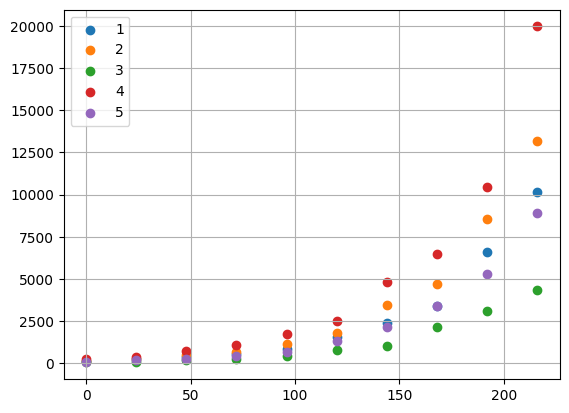

In [1712]:
plt.grid()
for i in range(data.shape[1]):
    plt.scatter(time, data[:, i])
plt.legend(range(1, data.shape[1] + 1))

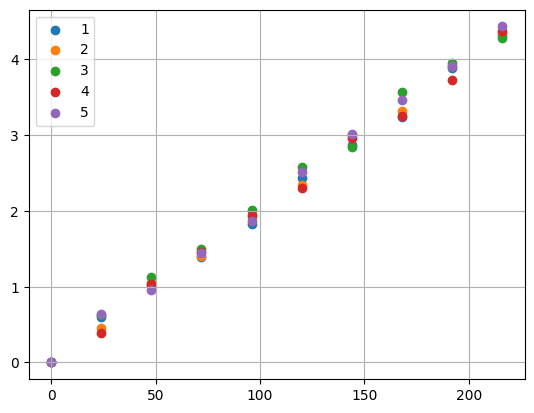

In [1713]:
plt.grid()
for i in range(ln_x0.shape[1]):
    plt.scatter(time, ln_x0[:, i])
plt.legend(range(1, ln_x0.shape[1] + 1))

In [1714]:
for i in range(5):
    print(i + 1)
    lm(time, ln_x0[:, i], verbose=5)
    print()

1
b_significance (_alpha = 0.05)
_t_crit = np.float64(2.2621571628540993)
n            param     t-stat    std err    p_value
const        0.020    113.788      0.000     0.0000             

R2_res(R2=np.float64(0.9975546471977701), R2_agj=np.float64(0.9975546471977701))

F-test (_alpha = 0.05)
_F = np.float64(3671.4505230463856)
_F_crit = np.float64(5.117355029199227)
_p_value = np.float64(2.1003928423609682e-29)
_F > _F_crit = np.True_ - H_0 отвергаем

Residuals normality: NormaltestResult(statistic=np.float64(0.28630358310364545), pvalue=np.float64(0.8666225129351169))
Residuals normality: ShapiroResult(statistic=np.float64(0.9667181247179206), pvalue=np.float64(0.8588615220386611))

2
b_significance (_alpha = 0.05)
_t_crit = np.float64(2.2621571628540993)
n            param     t-stat    std err    p_value
const        0.020    132.411      0.000     0.0000             

R2_res(R2=np.float64(0.9982322404881668), R2_agj=np.float64(0.9982322404881668))

F-test (_alpha = 0.05)
_F = n

c:\Users\foler\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [1715]:
r = (ln_x0.T @ time) / (time.T @ time)
r.T

array([[0.01990818, 0.02014672, 0.0205409 , 0.01985067, 0.02054102]])

In [1716]:
T = np.log(2) / r
T.T

array([[34.81720884, 34.40496785, 33.74473425, 34.9180736 , 33.74453505]])

In [1717]:
np.median(r), np.median(T)

(np.float64(0.020146717866919704), np.float64(34.404967853253744))

## 2.
Подберите наиболее качественную модель зависимости цены квартиры от количественных и качественных факторов.
1. Интерпретируйте коэффициенты модели.
2. Интерпретируйте влияние этажа, категории дома, пешей доступности метро и квартала на цену квартиры.
3. Проверьте на гетероскедастичность остатки модели
    1. используйте несколько формальных тестов;
    2. Скорректируйте оценки ошибок при необходимости.
4. Проверьте на автокорреляцию остатки в модели стоимости квартир. Используйте тесты:
    1. Графический
    2. Дарбина-Уотсона (рассчитайте статистику DW самостоятельно и сравните со значением, которое выдаёт встроенный тест. Интерпретируйте результат. Используя данные таблиц распределения)
    3. Бреуша-Годфри.

In [1718]:
flats = pd.read_csv("../data/flats_moscow.txt", delimiter='\t').drop(["n"], axis=1)
flats_features0 = flats.keys().to_numpy().copy()
flats_features0[0] = "1"
flats_np = flats.to_numpy()
flats_x0 = flats_np.copy()
flats_x0[:, 0] = 1
flats_y = flats_np[:, 0]
flats

,price,totsp,livesp,kitsp,dist,metrdist,walk,brick,floor,code
0,81,58,40,6.0,12.5,7,1,1,1,3
1,75,44,28,6.0,13.5,7,1,0,1,6
2,128,70,42,6.0,14.5,3,1,1,1,3
3,95,61,37,6.0,13.5,7,1,0,1,1
4,330,104,60,11.0,10.5,7,0,1,1,3
...,...,...,...,...,...,...,...,...,...,...
2035,110,77,45,10.0,12.0,5,0,0,1,5
2036,95,60,43,6.0,9.0,5,0,0,1,4
2037,95,60,46,5.0,10.5,5,1,0,1,7
2038,129,76,48,10.0,12.5,5,0,0,1,3


In [1719]:
np.round(np.corrcoef(flats_np.T), 2)

array([[ 1.  ,  0.76,  0.73,  0.6 , -0.33, -0.15,  0.15,  0.26,  0.13, -0.09],
       [ 0.76,  1.  ,  0.86,  0.78, -0.11, -0.04,  0.01,  0.12,  0.11, -0.02],
       [ 0.73,  0.86,  1.  ,  0.57, -0.2 , -0.05,  0.06,  0.25,  0.09, -0.01],
       [ 0.6 ,  0.78,  0.57,  1.  , -0.06, -0.03, -0.01, -0.02,  0.12, -0.05],
       [-0.33, -0.11, -0.2 , -0.06,  1.  ,  0.1 , -0.18, -0.39,  0.02, -0.19],
       [-0.15, -0.04, -0.05, -0.03,  0.1 ,  1.  , -0.04, -0.07, -0.02, -0.  ],
       [ 0.15,  0.01,  0.06, -0.01, -0.18, -0.04,  1.  ,  0.15, -0.02, -0.04],
       [ 0.26,  0.12,  0.25, -0.02, -0.39, -0.07,  0.15,  1.  , -0.05,  0.05],
       [ 0.13,  0.11,  0.09,  0.12,  0.02, -0.02, -0.02, -0.05,  1.  , -0.05],
       [-0.09, -0.02, -0.01, -0.05, -0.19, -0.  , -0.04,  0.05, -0.05,  1.  ]])

In [1720]:
flats_codes = pd.get_dummies(flats_x0[:, -1])
flats_codes

,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0
0,False,False,True,False,False,False,False,False
1,False,False,False,False,False,True,False,False
2,False,False,True,False,False,False,False,False
3,True,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...
2035,False,False,False,False,True,False,False,False
2036,False,False,False,True,False,False,False,False
2037,False,False,False,False,False,False,True,False
2038,False,False,True,False,False,False,False,False


In [1721]:
flats_x0[:, :-1], flats_codes.to_numpy().astype(int)[:, 1:]

(array([[ 1., 58., 40., ...,  1.,  1.,  1.],
        [ 1., 44., 28., ...,  1.,  0.,  1.],
        [ 1., 70., 42., ...,  1.,  1.,  1.],
        ...,
        [ 1., 60., 46., ...,  1.,  0.,  1.],
        [ 1., 76., 48., ...,  0.,  0.,  1.],
        [ 1., 64., 45., ...,  1.,  0.,  1.]], shape=(2040, 9)),
 array([[0, 1, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 1, 0, 0],
        [0, 1, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 1, 0],
        [0, 1, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(2040, 7)))

In [1722]:
flats_x = np.concat([flats_x0[:, :-1], flats_codes.to_numpy().astype(int)[:, 1:]], axis=-1)
flats_x

array([[ 1., 58., 40., ...,  0.,  0.,  0.],
       [ 1., 44., 28., ...,  1.,  0.,  0.],
       [ 1., 70., 42., ...,  0.,  0.,  0.],
       ...,
       [ 1., 60., 46., ...,  0.,  1.,  0.],
       [ 1., 76., 48., ...,  0.,  0.,  0.],
       [ 1., 64., 45., ...,  0.,  0.,  0.]], shape=(2040, 16))

In [1723]:
flats_features = np.concat([flats_features0[:-1], [f"code{i}" for i in range(2, 9)]])
flats_features

array(['1', 'totsp', 'livesp', 'kitsp', 'dist', 'metrdist', 'walk', 'brick', 'floor', 'code2',
       'code3', 'code4', 'code5', 'code6', 'code7', 'code8'], dtype=object)

In [1724]:
n = flats_x0.shape[0]
k = flats_features.shape[0]
n, k

(2040, 16)

In [1725]:
flats_b = lm(flats_x, flats_y, verbose=5, _x_names=flats_features)

b_significance (_alpha = 0.05)
_t_crit = np.float64(1.9611367446040437)
n            param     t-stat    std err    p_value
const      -28.373     -5.162      5.496     0.0000            1
1            1.706     14.859      0.115     0.0000        totsp
2            1.051      6.028      0.174     0.0000       livesp
3            1.839      4.777      0.385     0.0000        kitsp
4           -2.882    -13.119      0.220     0.0000         dist
5           -1.270     -7.605      0.167     0.0000     metrdist
6           11.879      8.355      1.422     0.0000         walk
7            3.007      1.908      1.576     0.0566        brick
8            6.660      4.276      1.558     0.0000        floor
9           -3.054     -1.143      2.672     0.2532        code2
10           6.819      2.911      2.343     0.0036        code3
11           3.211      1.219      2.634     0.2230        code4
12         -21.915     -9.331      2.349     0.0000        code5
13         -15.999     -6.463  

In [1726]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white

def white_het(_b: np.ndarray, _X: np.ndarray, _y: np.ndarray) -> tuple[float, int]:
    _x = _X
    _y_hat = _X @ _b

    _e = (_y - _y_hat)

    _is_intercept = np.isclose(_X[:, 0], 1).all()

    if _is_intercept:
        _x = _X
    else:
        _x = np.pad(_X, ((0,0),(1,0)), constant_values=1)


    _n, _k = _x.shape

    i0, i1 = np.triu_indices(_k)
    _xx = _x[:, i0] * _x[:, i1]
    
    # print(sm.OLS(_e**2, _xx).fit().summary())

    _bb = lm(_xx, _e**2, mode="pinv", verbose=10)

    print("statmodels:", het_white(_e, _x))

    _df = np.linalg.matrix_rank(_xx) - 1
    _R2 = R2_calc(_bb, _xx, _e**2)[0]

    _nR2 = _n * _R2

    print()
    print(f"nR2 = {_nR2}\np_value = {stats.chi2.sf(_nR2, df=_df)}")
    print()

    return _R2, _df
    

hw = white_het(flats_b, flats_x, flats_y)
hw

b_significance (_alpha = 0.05)
_t_crit = np.float64(1.9612107042565896)
n            param     t-stat    std err    p_value
const    36210.492      9.268   3907.173     0.0000             
1          425.229      3.892    109.270     0.0001             
2        -2566.908    -16.218    158.276     0.0000             
3         2218.284      6.045    366.969     0.0000             
4          -28.095     -0.099    284.768     0.9214             
5         -764.902     -4.015    190.533     0.0001             
6          121.342      0.145    835.446     0.8845             
7          819.181      1.102    743.536     0.2707             
8        -1078.033     -1.326    812.756     0.1849             
9         1046.806      0.619   1690.822     0.5359             
10        4220.435      3.495   1207.722     0.0005             
11       -7319.826     -5.914   1237.700     0.0000             
12        -201.107     -0.152   1327.283     0.8796             
13        3142.766      2.373  

C:\Users\foler\AppData\Local\Temp\ipykernel_14636\1935674219.py:17: RuntimeWarning: invalid value encountered in divide
  _t = _b / _std_b


statmodels: (np.float64(1168.2990471214512), np.float64(1.7732216913081264e-179), np.float64(24.93642159216253), np.float64(1.181363867041148e-283))

nR2 = 1168.2990471172227
p_value = 1.773221694730425e-179



(np.float64(0.5726956113319719), np.int64(104))

In [1727]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white

# Prepare data with add_constant()
X = sm.add_constant(flats_x)
y = flats_y

# Fit model
model = sm.OLS(y, X).fit()

# Perform White's test
het_white(model.resid, model.model.exog)

(np.float64(1168.299047121465),
 np.float64(1.7732216912968136e-179),
 np.float64(24.93642159216323),
 np.float64(1.181363867023554e-283))

In [1728]:
def GQ(_b: np.ndarray, _X: np.ndarray, _y: np.ndarray, _index: int, _alpha:float=0.05):
    _y_hat = _X @ _b
    _e2 = (_y - _y_hat) ** 2
    _sort_idx = np.argsort(_X[:, _index])
    _e2s = _e2[_sort_idx]

    _n = _e2s.shape[0]

    # _m = 3 * _n//8
    _m = 800

    _e21 = _e2s[:_m].sum()
    _e22 = _e2s[-_m:].sum()
    
    # print(_e21, _e22)

    _F = _e22 / _e21

    _F_crit = stats.f.ppf(1 - _alpha, _m - 1, _m - 1)
    _p_value = stats.f.sf(_F, _m, _m)

    print(f"F = {_F}\nF_crit({_alpha}, {_m}, {_m}) = {_F_crit}\np_value = {_p_value}")


for i in range(flats_b.shape[0]):
    GQ(flats_b, flats_x, flats_y, i)
    print()

# GQ(flats_b, flats_x, flats_y, 1)

F = 1.0473663512817335
F_crit(0.05, 800, 800) = 1.1235021887803087
p_value = 0.25647632402384474

F = 8.701258745581594
F_crit(0.05, 800, 800) = 1.1235021887803087
p_value = 2.77675780192209e-175

F = 5.578732292387055
F_crit(0.05, 800, 800) = 1.1235021887803087
p_value = 1.7001437543895645e-117

F = 5.702163834174412
F_crit(0.05, 800, 800) = 1.1235021887803087
p_value = 3.719040316182683e-120

F = 0.2947902238618259
F_crit(0.05, 800, 800) = 1.1235021887803087
p_value = 0.9999999999999999

F = 0.5806823967600401
F_crit(0.05, 800, 800) = 1.1235021887803087
p_value = 0.999999999999989

F = 1.6381123872567085
F_crit(0.05, 800, 800) = 1.1235021887803087
p_value = 1.9237530104427863e-12

F = 3.4960349395698223
F_crit(0.05, 800, 800) = 1.1235021887803087
p_value = 2.4783434323107544e-66

F = 1.4169946962744369
F_crit(0.05, 800, 800) = 1.1235021887803087
p_value = 4.435671722827025e-07

F = 0.8956493416194409
F_crit(0.05, 800, 800) = 1.1235021887803087
p_value = 0.9403444489623727

F = 1.6883

In [1729]:
def GQ2(_X: np.ndarray, _y: np.ndarray, _index: int, _alpha:float=0.05):
    _sort_idx = np.argsort(_X[:, _index])

    _n = _y.shape[0]
    _m = 3 * _n//8

    _Xs = _X[_sort_idx, :]
    _ys = _y[_sort_idx]

    _b1 = lm(_Xs[:_m], _ys[:_m], verbose=0)
    _b2 = lm(_Xs[-_m:], _ys[-_m:], verbose=0)

    _e21 = ((_ys[:_m] - _Xs[:_m] @ _b1)**2).sum()
    _e22 = ((_ys[-_m:] - _Xs[-_m:] @ _b2)**2).sum()

    _F =  _e22 / _e21

    # print(_e21, _e22)

    _F_crit = stats.f.ppf(1 - _alpha, _m - 1, _m - 1)
    _p_value = stats.f.sf(_F, _m, _m)

    print(f"F = {_F}\nF_crit({_alpha}, {_m}, {_m}) = {_F_crit}\np_value = {_p_value}")


for i in range(flats_b.shape[0]):
    GQ(flats_b, flats_x, flats_y, i)
    print()

# GQ2(flats_x, flats_y, 1)

F = 1.0473663512817335
F_crit(0.05, 800, 800) = 1.1235021887803087
p_value = 0.25647632402384474

F = 8.701258745581594
F_crit(0.05, 800, 800) = 1.1235021887803087
p_value = 2.77675780192209e-175

F = 5.578732292387055
F_crit(0.05, 800, 800) = 1.1235021887803087
p_value = 1.7001437543895645e-117

F = 5.702163834174412
F_crit(0.05, 800, 800) = 1.1235021887803087
p_value = 3.719040316182683e-120

F = 0.2947902238618259
F_crit(0.05, 800, 800) = 1.1235021887803087
p_value = 0.9999999999999999

F = 0.5806823967600401
F_crit(0.05, 800, 800) = 1.1235021887803087
p_value = 0.999999999999989

F = 1.6381123872567085
F_crit(0.05, 800, 800) = 1.1235021887803087
p_value = 1.9237530104427863e-12

F = 3.4960349395698223
F_crit(0.05, 800, 800) = 1.1235021887803087
p_value = 2.4783434323107544e-66

F = 1.4169946962744369
F_crit(0.05, 800, 800) = 1.1235021887803087
p_value = 4.435671722827025e-07

F = 0.8956493416194409
F_crit(0.05, 800, 800) = 1.1235021887803087
p_value = 0.9403444489623727

F = 1.6883

In [1730]:
from statsmodels.stats.diagnostic import het_goldfeldquandt

het_goldfeldquandt(flats_y, flats_x, 1, drop=0.25, split=3/8)

(np.float64(12.378769632215532),
 np.float64(1.6869099607646178e-211),
 'increasing')

Тесты показывают отвержение $H_0$, значит стандартные ошибки гетероскедастичные

In [1735]:
_ = lm(flats_x, flats_y, verbose=5, _x_names=flats_features, is_white_err=True)

b_significance (_alpha = 0.05)
_t_crit = np.float64(1.9611367446040437)
n            param     t-stat    std err    p_value
const      -28.373     -0.073    389.792     0.9420            1
1            1.706      0.277      6.149     0.7815        totsp
2            1.051      0.077     13.616     0.9385       livesp
3            1.839      0.090     20.383     0.9281        kitsp
4           -2.882     -0.435      6.619     0.6633         dist
5           -1.270     -0.280      4.529     0.7792     metrdist
6           11.879      0.340     34.931     0.7338         walk
7            3.007      0.059     50.735     0.9527        brick
8            6.660      0.180     36.927     0.8569        floor
9           -3.054     -0.050     60.661     0.9599        code2
10           6.819      0.090     75.390     0.9279        code3
11           3.211      0.032     99.321     0.9742        code4
12         -21.915     -0.343     63.973     0.7320        code5
13         -15.999     -0.271  

In [1736]:
_ = lm(flats_x, flats_y, verbose=5, _x_names=flats_features)

b_significance (_alpha = 0.05)
_t_crit = np.float64(1.9611367446040437)
n            param     t-stat    std err    p_value
const      -28.373     -5.162      5.496     0.0000            1
1            1.706     14.859      0.115     0.0000        totsp
2            1.051      6.028      0.174     0.0000       livesp
3            1.839      4.777      0.385     0.0000        kitsp
4           -2.882    -13.119      0.220     0.0000         dist
5           -1.270     -7.605      0.167     0.0000     metrdist
6           11.879      8.355      1.422     0.0000         walk
7            3.007      1.908      1.576     0.0566        brick
8            6.660      4.276      1.558     0.0000        floor
9           -3.054     -1.143      2.672     0.2532        code2
10           6.819      2.911      2.343     0.0036        code3
11           3.211      1.219      2.634     0.2230        code4
12         -21.915     -9.331      2.349     0.0000        code5
13         -15.999     -6.463  

In [1754]:
m = sm.OLS(flats_y, flats_x).fit()
# m.summary()

In [1755]:
flats_e = (flats_y - flats_x @ flats_b)

Проверим автокорреляцию остатков

1. Графически

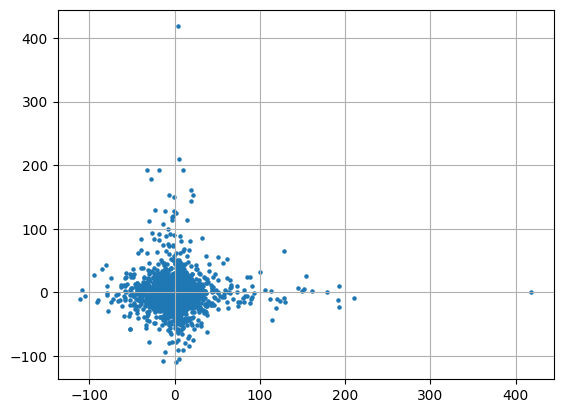

In [1759]:
plt.grid()
plt.scatter(flats_e[:-1], flats_e[1:], s=5)

2. Дарбина-Уотсона

In [1762]:
DW = ((flats_e[:-1] - flats_e[1:])**2).sum() / (flats_e**2).sum()
DW

np.float64(2.0407069729345264)

In [1764]:
from statsmodels.stats.stattools import durbin_watson

durbin_watson(flats_e)

np.float64(2.0407069729345264)

In [1768]:
r = (flats_e[:-1] * flats_e[1:]).sum() / np.sqrt( (flats_e[:-1]**2).sum() * (flats_e[1:]**2).sum() )
r, 2*(1-r)

(np.float64(-0.0205784581492984), np.float64(2.041156916298597))

Значение около 2, что говорит об отсутствии автокорреляции остатков.

Точных значений не нашёл, но примерно
$dL \approx 1.84, dU \approx 1.89 \,  (\alpha = 0.05) $

In [1778]:
dl = 1.84
du = 1.89

print(f"""{4 - dl < DW < 4 = } - H_1, p < 0
{4 - du < DW < 4 - dl = } - N/A
{-du < DW < 4 - du = } - H_0
{-dl < DW < 4 - dl = } - N/A
{0 < DW < dl = } - H_1, p > 0
""")

4 - dl < DW < 4 = np.False_ - H_1, p < 0
4 - du < DW < 4 - dl = np.False_ - N/A
-du < DW < 4 - du = np.True_ - H_0
-dl < DW < 4 - dl = np.True_ - N/A
0 < DW < dl = np.False_ - H_1, p > 0



3. Бреуша-Годфри.

In [1797]:
ey1 = flats_e[1:]
ex1 = flats_e[None, :-1].T

ey2 = flats_e[2:]
ex2 = np.concat([flats_e[None, :-2], flats_e[None, 1:-1]], axis=0).T

ex2

array([[-26.09452681,  33.10666871],
       [ 33.10666871,  -0.98438365],
       [ -0.98438365,  -1.35154268],
       ...,
       [ -2.48123497, -12.79252227],
       [-12.79252227,  -6.14611147],
       [ -6.14611147, -12.22135884]], shape=(2038, 2))

In [1807]:
lm(ex1, ey1)

b_significance (_alpha = 0.05)
_t_crit = np.float64(1.9611286836476967)
n            param     t-stat    std err    p_value
0           -0.021     -0.929      0.022     0.3529             

R2_res(R2=np.float64(0.0004232658949581136), R2_agj=np.float64(0.0004232658949581136))

F-test (_alpha = 0.05)
_F = np.float64(0.8629811644195255)
_F_crit = np.float64(3.846025713825688)
_p_value = np.float64(0.1941246821000312)
_F > _F_crit = np.False_ - H_0 отвергаем

Residuals normality: NormaltestResult(statistic=np.float64(1574.0044091477278), pvalue=np.float64(0.0))
Residuals normality: ShapiroResult(statistic=np.float64(0.7946359443267654), pvalue=np.float64(4.8609934260732873e-45))


array([-0.02057431])

In [1808]:
lm(ex2, ey2)

b_significance (_alpha = 0.05)
_t_crit = np.float64(1.961129828421701)
n            param     t-stat    std err    p_value
0            0.037      1.670      0.022     0.0951             
1           -0.019     -0.871      0.022     0.3838             

R2_res(R2=np.float64(0.001769697141943416), R2_agj=np.float64(0.0012794072093019748))

F-test (_alpha = 0.05)
_F = np.float64(3.609491087057431)
_F_crit = np.float64(3.8460302039262477)
_p_value = np.float64(0.00015710461120971815)
_F > _F_crit = np.False_ - H_0 отвергаем

Residuals normality: NormaltestResult(statistic=np.float64(1573.404818622235), pvalue=np.float64(0.0))
Residuals normality: ShapiroResult(statistic=np.float64(0.7948093867857777), pvalue=np.float64(5.109642185402107e-45))


array([ 0.03697005, -0.01928466])